Drive link : https://drive.google.com/drive/folders/1TrYtYr3LLTRp6nBxUjdy4I88LlaDFWGz?usp=sharing

####Section 1 — Setup (Drive mount + Seeds + Imports)
####Section 2 — Load CSV + CDR Label Matching
####Section 3 — Preprocessing Pipeline (Main MRI Loop)
####Section 4 — Save Arrays to Drive
####Section 5 — Augmentation
####Section 6 — Combine + Shuffle + Split + Encode + Save
####Section 7 — Model Building
####Section 8 — Phase 1 Training
####Section 9 — Phase 2 Fine Tuning
####Section 10 — Training Curves
####Section 11 — Evaluation
####Section 12 — Grad-CAM



In [3]:
#-------------------Section 1 — SETUP ---------------------

from google.colab import drive
drive.mount('/content/drive')

import random
import numpy as np
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

Mounted at /content/drive


In [4]:
#----------------------- IMPORTS----------------------
import os
import cv2
import nibabel as nib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('All libraries imported!')

All libraries imported!


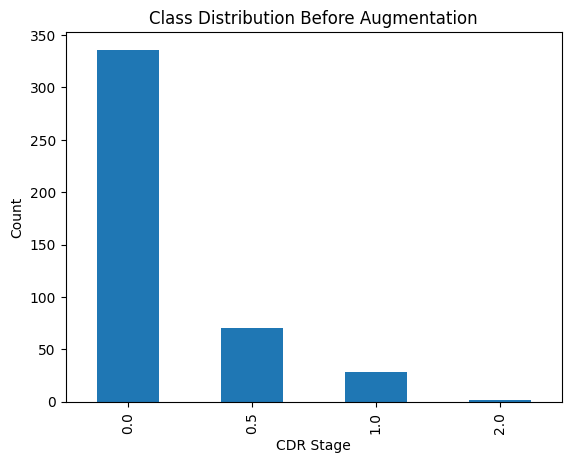

In [4]:
# ----------------- Section 2 - LOAD CSV ----------------------------
df=pd.read_excel('/content/drive/MyDrive/oasis_cross-sectional-5708aa0a98d82080.xlsx')
df['CDR']=df['CDR'].fillna(0.0)
df['CDR'].isna().sum()
df['CDR'].value_counts()

df['CDR'].value_counts().plot(kind='bar')
plt.title('Class Distribution Before Augmentation')
plt.ylabel('Count')
plt.xlabel('CDR Stage')
plt.savefig('/content/drive/MyDrive/class_distribution_before.png',dpi=300, bbox_inches='tight')
plt.show()


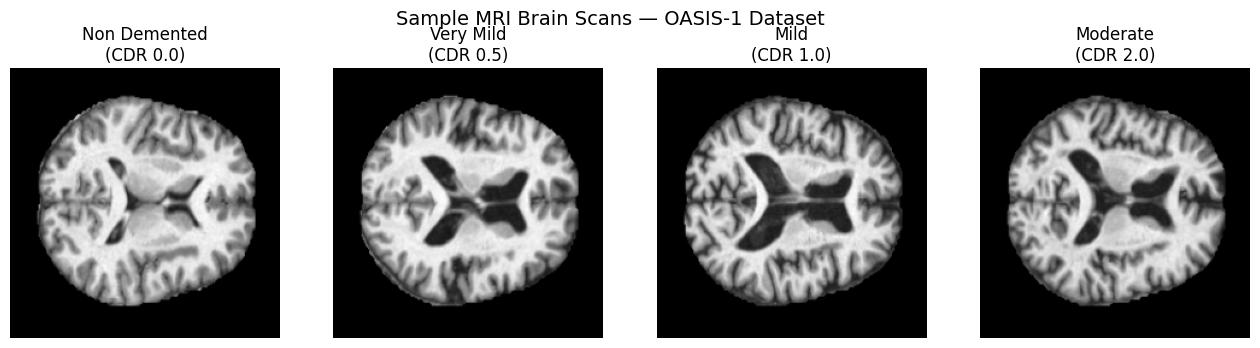

Sample MRI saved!


In [49]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

class_names = ['Non Demented', 'Very Mild', 'Mild', 'Moderate']
label_values = [0.0, 0.5, 1.0, 2.0]

for i, (cls_name, lbl) in enumerate(zip(class_names, label_values)):
    idx = np.where(array_label == lbl)[0][0]
    axes[i].imshow(array_image[idx], cmap='gray')
    axes[i].set_title(f'{cls_name}\n(CDR {lbl})')
    axes[i].axis('off')

plt.suptitle('Sample MRI Brain Scans — OASIS-1 Dataset', fontsize=14)
plt.savefig('/content/drive/MyDrive/sample_mri.png', dpi=300, bbox_inches='tight')
plt.show()
print('Sample MRI saved!')

In [5]:
#---------------------CDR Label Matching-------------------
cdr_match={}
items=os.listdir('/content/drive/MyDrive/Dataset')
base_path = '/content/drive/MyDrive/Dataset'
pos=1
for i in items:
  disc_path=i
  address=os.path.join(base_path,disc_path,'disc'+str(pos))
  patients=os.listdir(address)
  for j in patients:
    matching_rows=df[df['ID']==j]
    cdr_match[j]=float(matching_rows['CDR'].values[0])
  pos=pos+1
print(cdr_match)
print(len(cdr_match))


{'OAS1_0041_MR1': 0.5, 'OAS1_0040_MR1': 0.0, 'OAS1_0037_MR1': 0.0, 'OAS1_0042_MR1': 0.5, 'OAS1_0038_MR1': 0.0, 'OAS1_0039_MR1': 0.5, 'OAS1_0035_MR1': 1.0, 'OAS1_0031_MR1': 1.0, 'OAS1_0033_MR1': 0.0, 'OAS1_0034_MR1': 0.0, 'OAS1_0030_MR1': 0.0, 'OAS1_0028_MR1': 1.0, 'OAS1_0032_MR1': 0.0, 'OAS1_0027_MR1': 0.0, 'OAS1_0029_MR1': 0.0, 'OAS1_0026_MR1': 0.0, 'OAS1_0023_MR1': 0.5, 'OAS1_0025_MR1': 0.0, 'OAS1_0020_MR1': 0.0, 'OAS1_0018_MR1': 0.0, 'OAS1_0022_MR1': 0.5, 'OAS1_0021_MR1': 0.5, 'OAS1_0019_MR1': 0.0, 'OAS1_0016_MR1': 0.5, 'OAS1_0017_MR1': 0.0, 'OAS1_0015_MR1': 0.5, 'OAS1_0013_MR1': 0.0, 'OAS1_0012_MR1': 0.0, 'OAS1_0014_MR1': 0.0, 'OAS1_0011_MR1': 0.0, 'OAS1_0010_MR1': 0.0, 'OAS1_0009_MR1': 0.0, 'OAS1_0007_MR1': 0.0, 'OAS1_0005_MR1': 0.0, 'OAS1_0006_MR1': 0.0, 'OAS1_0004_MR1': 0.0, 'OAS1_0001_MR1': 0.0, 'OAS1_0002_MR1': 0.0, 'OAS1_0003_MR1': 0.5, 'OAS1_0074_MR1': 0.0, 'OAS1_0078_MR1': 0.0, 'OAS1_0079_MR1': 0.0, 'OAS1_0076_MR1': 0.0, 'OAS1_0068_MR1': 0.0, 'OAS1_0073_MR1': 1.0, 'OAS1_007

In [6]:
!pip install nibabel

In [8]:
#--------------------Section 3 -PREPROCESSING PIPELINE------------------------
MRI_images=[]
MRI_labels=[]
pos=1
count=0
items=os.listdir('/content/drive/MyDrive/Dataset')
#print(items)
base_path = '/content/drive/MyDrive/Dataset'
for i in items:
  disc_path=i
  disc_number=i.replace('oasis_cross-sectional_disc','')
  address=os.path.join(base_path,disc_path,'disc'+disc_number)
  patients=os.listdir(address)
  for patient in patients:
    if(patient.endswith('MR1')):
      image_path=os.path.join(address,patient,'PROCESSED/MPRAGE/T88_111')
      files_list=os.listdir(image_path)
      file_masked=[f for f in files_list if 'masked_gfc.img' in f]
      path_mri=os.path.join(image_path,file_masked[0])
      load_mri=nib.load(path_mri)
      data_3d=load_mri.get_fdata()  #get_fdata() extracts the actual 3D array of pixel values
      data_3d=data_3d.squeeze()
      centre_s=data_3d.shape[2]//2
      img_2d=data_3d[:,:,centre_s]
      resized=cv2.resize(img_2d,(224,224))
      if(resized.max()==0):    #Otherwise causes 0 division error
        continue
      normalised_img=resized/resized.max()
      r_g_b=np.stack([normalised_img,normalised_img,normalised_img],axis=2)
      labels=cdr_match[patient]
      MRI_labels.append(labels)
      MRI_images.append(r_g_b)
      if len(file_masked) == 0:
        print(f'No masked file found for: {patient}')
        count=count+1
        continue



In [9]:
print(len(MRI_labels))
print(len(MRI_images))

416
416


In [10]:
array_label=np.array(MRI_labels)
array_image=np.array(MRI_images)
print(array_label.shape)
print(array_image.shape)

(416,)
(416, 224, 224, 3)


In [11]:
#--------------------------Section 4 - SAVE ARRAYS TO DRIVE--------------------------------

np.save('/content/drive/MyDrive/array_image.npy', array_image)
np.save('/content/drive/MyDrive/array_label.npy', array_label)
array_image = np.load('/content/drive/MyDrive/array_image.npy')
array_label = np.load('/content/drive/MyDrive/array_label.npy')
print(array_label.shape)
print(array_image.shape)
print('Preprocessing saved!')

(416,)
(416, 224, 224, 3)
Preprocessing saved!


In [12]:
# ---------------------LABEL DISTRIBUTION CHECK-----------------------
cdr_values,counts=np.unique(array_label,return_counts=True)
print(dict(zip(cdr_values, counts)))

{np.float64(0.0): np.int64(316), np.float64(0.5): np.int64(70), np.float64(1.0): np.int64(28), np.float64(2.0): np.int64(2)}


In [13]:
#-------------------SEPERATE CLASSES FOR AUGMENTATION--------------------
x_0 = array_image[array_label == 0.0]
x_05 = array_image[array_label == 0.5]
x_1 = array_image[array_label == 1.0]
x_2 = array_image[array_label == 2.0]


In [14]:
#-------------------------Section 5-DATA AUGMENTATION---------------------------------
augmentor = ImageDataGenerator(
    rotation_range=10,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

In [15]:
augmented_image = []
augmented_label = []

# Scale all minority classes to 0-255
x_05_scaled = (x_05 * 255).astype('uint8')
x_1_scaled = (x_1 * 255).astype('uint8')
x_2_scaled = (x_2 * 255).astype('uint8')

# CDR 0.5
count = 0
needed = 200 - len(x_05)
for item in augmentor.flow(x_05_scaled, batch_size=1):
    img = item[0] / 255.0
    augmented_image.append(img)
    augmented_label.append(0.5)
    count += 1
    if count >= needed:
        break

# CDR 1.0
count = 0
needed = 200 - len(x_1)
for item in augmentor.flow(x_1_scaled, batch_size=1):
    img = item[0] / 255.0
    augmented_image.append(img)
    augmented_label.append(1.0)
    count += 1
    if count >= needed:
        break

# CDR 2.0
count = 0
needed = 200 - len(x_2)
for item in augmentor.flow(x_2_scaled, batch_size=1):
    img = item[0] / 255.0
    augmented_image.append(img)
    augmented_label.append(2.0)
    count += 1
    if count >= needed:
        break

print(f'Total augmented: {len(augmented_image)}')

Total augmented: 500


In [16]:

#---------------------- Section 6 — COMBINE AND SHUFFLE-----------------------

# Convert augmented lists to arrays
augmented_array_image = np.array(augmented_image)
augmented_array_label = np.array(augmented_label)

# Combine original and augmented
i_final = np.concatenate([array_image, augmented_array_image], axis=0)
l_final = np.concatenate([array_label, augmented_array_label], axis=0)

# Shuffle
from sklearn.utils import shuffle
i_final, l_final = shuffle(i_final, l_final, random_state=42)

print(f'Total images: {len(i_final)}')
print('Final distribution:')
print({float(k): int(v) for k, v in zip(*np.unique(l_final, return_counts=True))})

Total images: 916
Final distribution:
{0.0: 316, 0.5: 200, 1.0: 200, 2.0: 200}


In [17]:
cdr_dist,counts=np.unique(l_final,return_counts=True)
print(dict(zip(cdr_dist, counts)))

{np.float64(0.0): np.int64(316), np.float64(0.5): np.int64(200), np.float64(1.0): np.int64(200), np.float64(2.0): np.int64(200)}


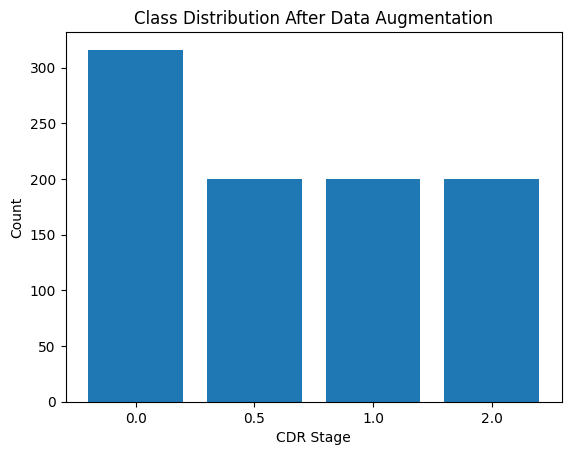

In [18]:
unique, counts = np.unique(l_final, return_counts=True)
plt.bar([str(float(u)) for u in unique], counts)
plt.title('Class Distribution After Data Augmentation')
plt.ylabel('Count')
plt.xlabel('CDR Stage')
plt.savefig('/content/drive/MyDrive/class_distribution_after.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
#-----------------------train-test split-------------------------------------
from sklearn.model_selection import train_test_split
l_train,l_temp,i_train,i_temp=train_test_split(l_final,i_final,test_size=0.3,random_state=42)
l_val,l_test,i_val,i_test=train_test_split(l_temp,i_temp,test_size=0.5,random_state=42)


In [20]:
#---------------------------one-hot encoding----------------------------
from tensorflow.keras.utils import to_categorical
label_map = {0.0: 0, 0.5: 1, 1.0: 2, 2.0: 3}
label_int=np.vectorize(label_map.get)
l_train_int = label_int(l_train)
l_val_int = label_int(l_val)
l_test_int = label_int(l_test)
y_train = to_categorical(l_train_int, num_classes=4)
y_val = to_categorical(l_val_int, num_classes=4)
y_test = to_categorical(l_test_int, num_classes=4)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)


(641, 4)
(137, 4)
(138, 4)


In [21]:
np.save('/content/drive/MyDrive/i_train_4class.npy', i_train)
np.save('/content/drive/MyDrive/i_val_4class.npy', i_val)
np.save('/content/drive/MyDrive/i_test_4class.npy', i_test)
np.save('/content/drive/MyDrive/y_train_4class.npy', y_train)
np.save('/content/drive/MyDrive/y_val_4class.npy', y_val)
np.save('/content/drive/MyDrive/y_test_4class.npy', y_test)
print('All splits saved to Drive!')

All splits saved to Drive!


In [22]:
#-----------------------Section 7 - MODEL BUILDING-------------------------------------
VGG16_base=VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
for layer in VGG16_base.layers:
   layer.trainable=False



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [23]:
#-------------------------------------MODEL BUILDING---------------------
x = Flatten()(VGG16_base.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(4, activation='softmax')(x)
VGG16_model=Model(inputs=VGG16_base.input,outputs=output)
VGG16_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model build successfully")
VGG16_model.summary()

Model build successfully


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           51

 Total params: 21,170,884 (80.76 MB)

 Trainable params: 6,456,196 (24.63 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [24]:
#----------------Section 8 - PHASE 1 TRAINING--------------------------
early_stopping= EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint= ModelCheckpoint(
    '/content/drive/MyDrive/model_4class_phase1.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print('4 Class training')
history_1 = VGG16_model.fit(
    i_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(i_val, y_val),
    callbacks=[early_stopping, checkpoint]
)

4 Class training
Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.3197 - loss: 3.6110 
Epoch 1: val_loss improved from None to 1.06892, saving model to /content/drive/MyDrive/model_4class_phase1.h5



Epoch 1: finished saving model to /content/drive/MyDrive/model_4class_phase1.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 573s 27s/step - accuracy: 0.3682 - loss: 2.6989 - val_accuracy: 0.5401 - val_loss: 1.0689
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.5641 - loss: 1.0342 
Epoch 2: val_loss improved from 1.06892 to 0.68878, saving model to /content/drive/MyDrive/model_4class_phase1.h5



Epoch 2: finished saving model to /content/drive/MyDrive/model_4class_phase1.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 563s 27s/step - accuracy: 0.5928 - loss: 0.9640 - val_accuracy: 0.7226 - val_loss: 0.6888
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.7120 - loss: 0.7387 
Epoch 3: val_loss improved from 0.68878 to 0.66271, saving model to /content/drive/MyDrive/model_4class_phase1.h5



Epoch 3: finished saving model to /content/drive/MyDrive/model_4class_phase1.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 558s 27s/step - accuracy: 0.7098 - loss: 0.7367 - val_accuracy: 0.6934 - val_loss: 0.6627
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.7322 - loss: 0.6566 
Epoch 4: val_loss improved from 0.66271 to 0.53060, saving model to /content/drive/MyDrive/model_4class_phase1.h5



Epoch 4: finished saving model to /content/drive/MyDrive/model_4class_phase1.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 504s 24s/step - accuracy: 0.7457 - loss: 0.6470 - val_accuracy: 0.7518 - val_loss: 0.5306
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.7459 - loss: 0.5698 
Epoch 5: val_loss improved from 0.53060 to 0.50462, saving model to /content/drive/MyDrive/model_4class_phase1.h5



Epoch 5: finished saving model to /content/drive/MyDrive/model_4class_phase1.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 553s 27s/step - accuracy: 0.7582 - loss: 0.5582 - val_accuracy: 0.7810 - val_loss: 0.5046
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.7964 - loss: 0.4879 
Epoch 6: val_loss did not improve from 0.50462
21/21 ━━━━━━━━━━━━━━━━━━━━ 552s 26s/step - accuracy: 0.7769 - loss: 0.5121 - val_accuracy: 0.7445 - val_loss: 0.5610
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8020 - loss: 0.4542 
Epoch 7: val_loss did not improve from 0.50462
21/21 ━━━━━━━━━━━━━━━━━━━━ 543s 26s/step - accuracy: 0.7972 - loss: 0.4739 - val_accuracy: 0.7299 - val_loss: 0.6627
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8218 - loss: 0.4246 
Epoch 8: val_loss did not improve from 0.50462
21/21 ━━━━━━━━━━━━━━━━━━━━ 542s 26s/step - accuracy: 0.7988 - loss: 0.4569 - val_accuracy: 0.7007 - val_loss: 0.6197
Epoch 9/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - acc

In [25]:
import json
with open('/content/drive/MyDrive/history_1.json', 'w') as f:
    json.dump(history_1.history, f)
print('Phase 1 history saved!')

Phase 1 history saved!


In [26]:
#-------------------------Section 9 - PHASE 2 FINE TUNING-------------------------------
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load best model
VGG16_model = load_model('/content/drive/MyDrive/model_4class_phase1.h5')
print('Best model loaded!')

# Unfreeze last 4 VGG16 layers
for layer in VGG16_model.layers[-4:]:
    layer.trainable = True

# Recompile with very small learning rate
VGG16_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stopping_2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_2 = ModelCheckpoint(
    '/content/drive/MyDrive/model_4class_final.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print('Phase 2 — Fine tuning')
history_2 = VGG16_model.fit(
    i_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(i_val, y_val),
    callbacks=[early_stopping_2, checkpoint_2]
)

Best model loaded!
Phase 2 — Fine tuning
Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8158 - loss: 0.4600 
Epoch 1: val_loss improved from None to 0.49933, saving model to /content/drive/MyDrive/model_4class_final.h5



Epoch 1: finished saving model to /content/drive/MyDrive/model_4class_final.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 558s 26s/step - accuracy: 0.7972 - loss: 0.4882 - val_accuracy: 0.7956 - val_loss: 0.4993
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8043 - loss: 0.4424 
Epoch 2: val_loss improved from 0.49933 to 0.49877, saving model to /content/drive/MyDrive/model_4class_final.h5



Epoch 2: finished saving model to /content/drive/MyDrive/model_4class_final.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 504s 24s/step - accuracy: 0.7785 - loss: 0.4995 - val_accuracy: 0.8029 - val_loss: 0.4988
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8152 - loss: 0.4651 
Epoch 3: val_loss improved from 0.49877 to 0.49749, saving model to /content/drive/MyDrive/model_4class_final.h5



Epoch 3: finished saving model to /content/drive/MyDrive/model_4class_final.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 553s 26s/step - accuracy: 0.7832 - loss: 0.4951 - val_accuracy: 0.8029 - val_loss: 0.4975
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8217 - loss: 0.4222 
Epoch 4: val_loss improved from 0.49749 to 0.49595, saving model to /content/drive/MyDrive/model_4class_final.h5



Epoch 4: finished saving model to /content/drive/MyDrive/model_4class_final.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 493s 23s/step - accuracy: 0.8050 - loss: 0.4415 - val_accuracy: 0.8029 - val_loss: 0.4959
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8054 - loss: 0.4501 
Epoch 5: val_loss improved from 0.49595 to 0.49138, saving model to /content/drive/MyDrive/model_4class_final.h5



Epoch 5: finished saving model to /content/drive/MyDrive/model_4class_final.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 557s 26s/step - accuracy: 0.7894 - loss: 0.4668 - val_accuracy: 0.8029 - val_loss: 0.4914
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8525 - loss: 0.3899 
Epoch 6: val_loss improved from 0.49138 to 0.48773, saving model to /content/drive/MyDrive/model_4class_final.h5



Epoch 6: finished saving model to /content/drive/MyDrive/model_4class_final.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 491s 23s/step - accuracy: 0.8409 - loss: 0.4142 - val_accuracy: 0.8102 - val_loss: 0.4877
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8351 - loss: 0.4238 
Epoch 7: val_loss did not improve from 0.48773
21/21 ━━━━━━━━━━━━━━━━━━━━ 496s 23s/step - accuracy: 0.8175 - loss: 0.4547 - val_accuracy: 0.8029 - val_loss: 0.4877
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8471 - loss: 0.4093 
Epoch 8: val_loss improved from 0.48773 to 0.48483, saving model to /content/drive/MyDrive/model_4class_final.h5



Epoch 8: finished saving model to /content/drive/MyDrive/model_4class_final.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 555s 26s/step - accuracy: 0.8066 - loss: 0.4451 - val_accuracy: 0.8029 - val_loss: 0.4848
Epoch 9/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8474 - loss: 0.4294 
Epoch 9: val_loss improved from 0.48483 to 0.48223, saving model to /content/drive/MyDrive/model_4class_final.h5



Epoch 9: finished saving model to /content/drive/MyDrive/model_4class_final.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 554s 27s/step - accuracy: 0.8331 - loss: 0.4378 - val_accuracy: 0.8029 - val_loss: 0.4822
Epoch 10/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8354 - loss: 0.3892 
Epoch 10: val_loss improved from 0.48223 to 0.48091, saving model to /content/drive/MyDrive/model_4class_final.h5



Epoch 10: finished saving model to /content/drive/MyDrive/model_4class_final.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 494s 23s/step - accuracy: 0.8284 - loss: 0.4086 - val_accuracy: 0.8102 - val_loss: 0.4809
Epoch 11/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8427 - loss: 0.3798 
Epoch 11: val_loss did not improve from 0.48091
21/21 ━━━━━━━━━━━━━━━━━━━━ 543s 26s/step - accuracy: 0.8393 - loss: 0.3984 - val_accuracy: 0.8029 - val_loss: 0.4817
Epoch 12/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8700 - loss: 0.3549 
Epoch 12: val_loss did not improve from 0.48091
21/21 ━━━━━━━━━━━━━━━━━━━━ 540s 26s/step - accuracy: 0.8565 - loss: 0.3878 - val_accuracy: 0.8029 - val_loss: 0.4844
Epoch 13/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8575 - loss: 0.3745 
Epoch 13: val_loss did not improve from 0.48091
21/21 ━━━━━━━━━━━━━━━━━━━━ 537s 26s/step - accuracy: 0.8456 - loss: 0.4038 - val_accuracy: 0.8102 - val_loss: 0.4827
Epoch 14/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/ste

In [27]:
with open('/content/drive/MyDrive/history_2.json', 'w') as f:
    json.dump(history_2.history, f)
print('Phase 2 history saved!')

Phase 2 history saved!


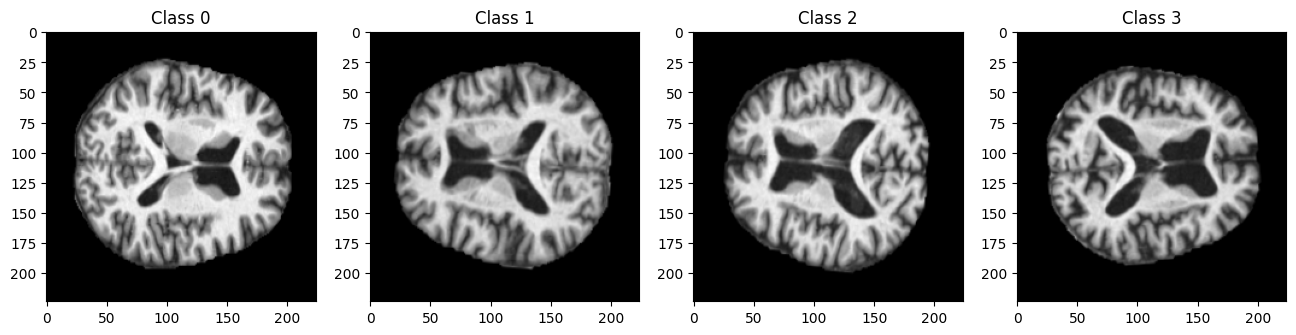

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for cls in range(4):
    idx = np.where(np.argmax(y_train, axis=1) == cls)[0][0]
    axes[cls].imshow(i_train[idx])
    axes[cls].set_title(f'Class {cls}')
plt.show()

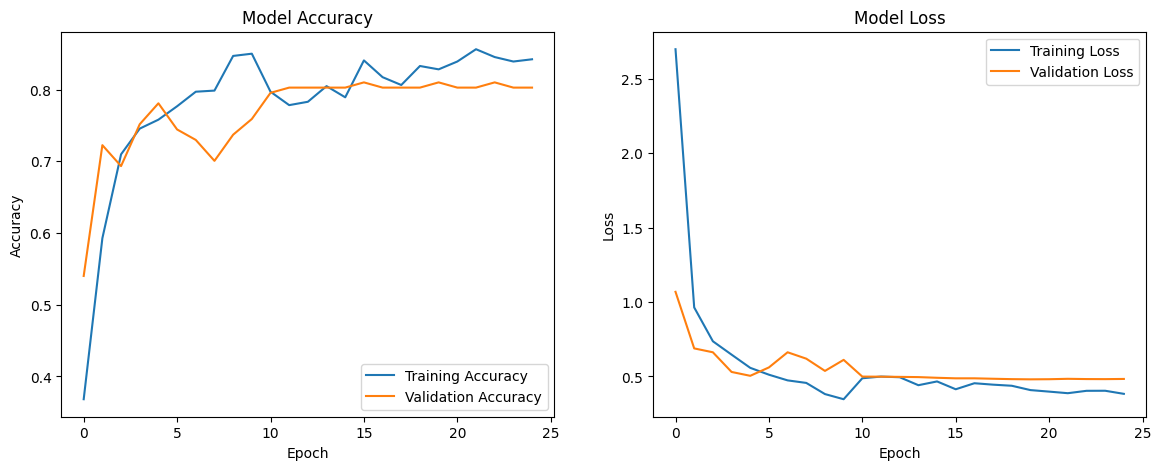

Training curves saved!


In [32]:
#-----------------Section 10 - TRAINING CURVES-------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combine Phase 1 and Phase 2 history
acc = history_1.history['accuracy'] + history_ft.history['accuracy']
val_acc = history_1.history['val_accuracy'] + history_ft.history['val_accuracy']
loss = history_1.history['loss'] + history_ft.history['loss']
val_loss = history_1.history['val_loss'] + history_ft.history['val_loss']

# Accuracy curve
axes[0].plot(acc, label='Training Accuracy')
axes[0].plot(val_acc, label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss curve
axes[1].plot(loss, label='Training Loss')
axes[1].plot(val_loss, label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.savefig('/content/drive/MyDrive/training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('Training curves saved!')

In [7]:
#-----------------------Section 11 — EVALUATION-----------------------------------

VGG16_model = load_model('/content/drive/MyDrive/model_4class_final.h5')
print('4-class model loaded!')

i_test = np.load('/content/drive/MyDrive/i_test_4class.npy')
y_test = np.load('/content/drive/MyDrive/y_test_4class.npy')
print(f'Test data loaded: {i_test.shape}')

4-class model loaded!
Test data loaded: (138, 224, 224, 3)


In [42]:
test_loss, test_accuracy = VGG16_model.evaluate(i_test, y_test)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 92s 17s/step - accuracy: 0.7971 - loss: 0.4692
Test Loss: 0.4692
Test Accuracy: 0.7971


In [43]:
import numpy as np

predictions = VGG16_model.predict(i_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

print('Predicted distribution:')
print(np.unique(predicted_classes, return_counts=True))
print('True distribution:')
print(np.unique(true_classes, return_counts=True))

4/5 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 87s 17s/step
Predicted distribution:
(array([0, 1, 2, 3]), array([44, 25, 36, 33]))
True distribution:
(array([0, 1, 2, 3]), array([35, 37, 33, 33]))


In [44]:
from tensorflow.keras.models import load_model
import numpy as np

VGG16_model = load_model('/content/drive/MyDrive/model_4class_final.h5')
i_test = np.load('/content/drive/MyDrive/i_test_4class.npy')
y_test = np.load('/content/drive/MyDrive/y_test_4class.npy')
i_train = np.load('/content/drive/MyDrive/i_train_4class.npy')
y_train = np.load('/content/drive/MyDrive/y_train_4class.npy')
i_val = np.load('/content/drive/MyDrive/i_val_4class.npy')
y_val = np.load('/content/drive/MyDrive/y_val_4class.npy')
print('All loaded!')

All loaded!


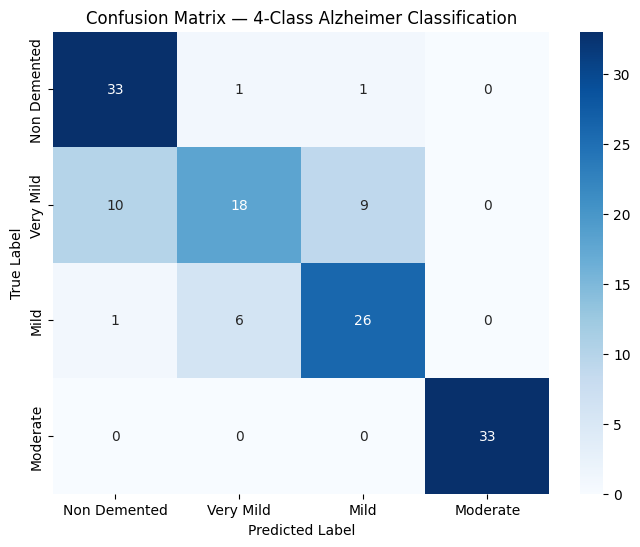

In [45]:
#----------------------------CONFUSION MATRIX--------------------------------------
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(true_classes,predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non Demented', 'Very Mild', 'Mild', 'Moderate'],
            yticklabels=['Non Demented', 'Very Mild', 'Mild', 'Moderate'])
plt.title('Confusion Matrix — 4-Class Alzheimer Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [46]:
from sklearn.metrics import classification_report

print(classification_report(true_classes, predicted_classes,
    target_names=['Non Demented', 'Very Mild', 'Mild', 'Moderate']))

              precision    recall  f1-score   support

Non Demented       0.75      0.94      0.84        35
   Very Mild       0.72      0.49      0.58        37
        Mild       0.72      0.79      0.75        33
    Moderate       1.00      1.00      1.00        33

    accuracy                           0.80       138
   macro avg       0.80      0.80      0.79       138
weighted avg       0.80      0.80      0.79       138



In [47]:
#----------------Section 12 - GRAD-CAM-----------------------------------
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from tensorflow.keras.models import Model

def generate_heatmap(model, image, class_index):
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer('block5_conv3').output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(np.array([image]))
        loss = preds[:, class_index]

    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / heatmap.max()
    return heatmap

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


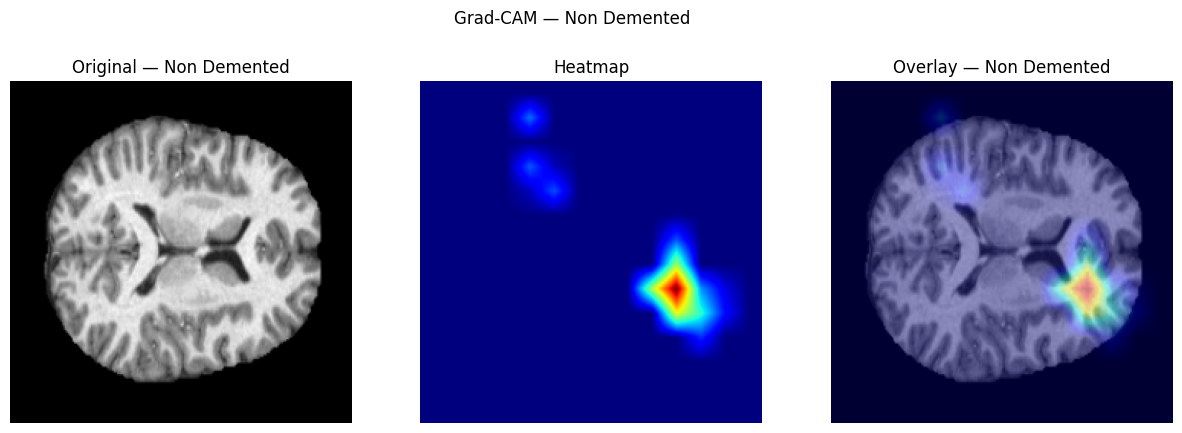

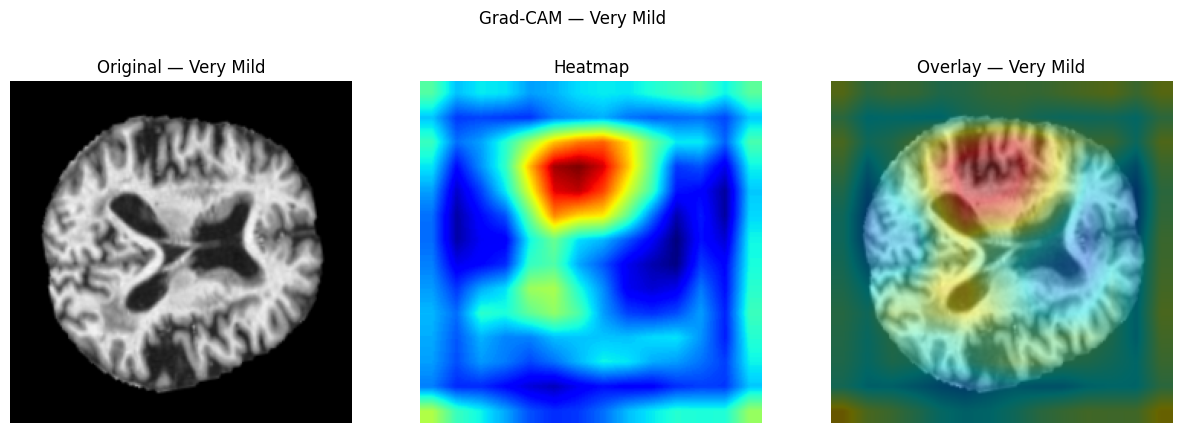

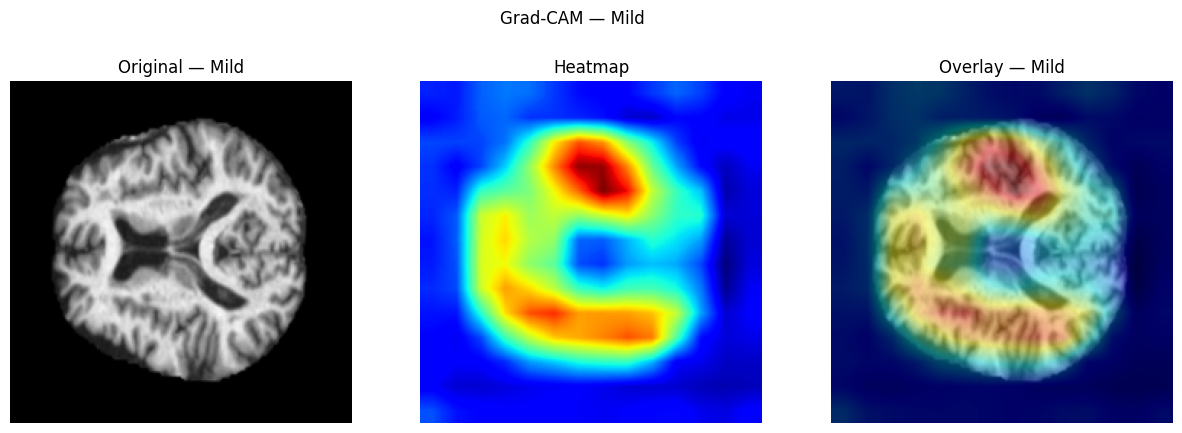

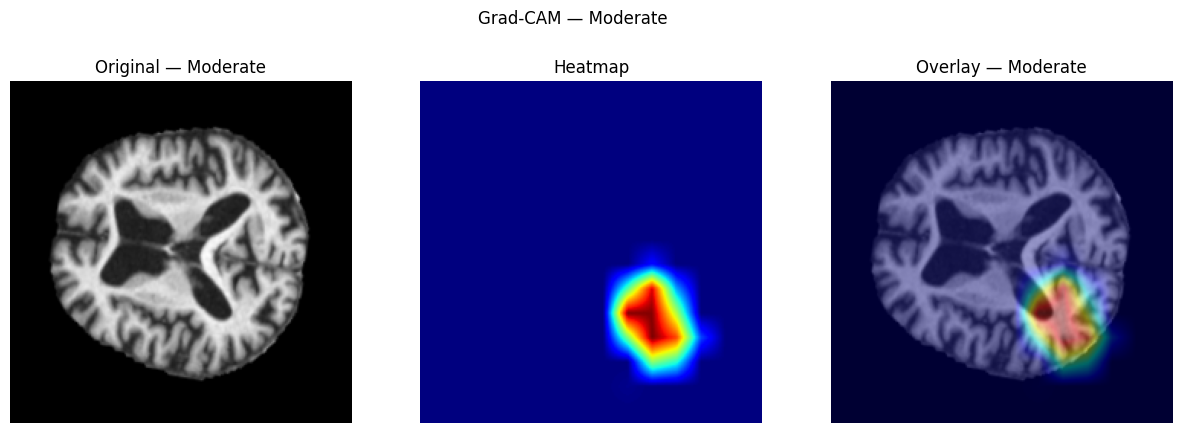

In [48]:
class_names = ['Non Demented', 'Very Mild', 'Mild', 'Moderate']

for cls in range(4):

    idx = np.where((true_classes == cls) & (predicted_classes == cls))[0]

    if len(idx) == 0:
        print(f'No correct predictions for {class_names[cls]}')
        continue

    image = i_test[idx[0]]
    heatmap = generate_heatmap(VGG16_model, image, cls)


    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap_colour = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_colour = cv2.cvtColor(heatmap_colour, cv2.COLOR_BGR2RGB)


    brain = np.uint8(255 * image)
    overlay = cv2.addWeighted(brain, 0.6, heatmap_colour, 0.4, 0)


    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title(f'Original — {class_names[cls]}')
    axes[0].axis('off')
    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('Heatmap')
    axes[1].axis('off')
    axes[2].imshow(overlay)
    axes[2].set_title(f'Overlay — {class_names[cls]}')
    axes[2].axis('off')
    plt.suptitle(f'Grad-CAM — {class_names[cls]}')
    plt.savefig(f'/content/drive/MyDrive/gradcam_{class_names[cls]}.png', dpi=300, bbox_inches='tight')
    plt.show()

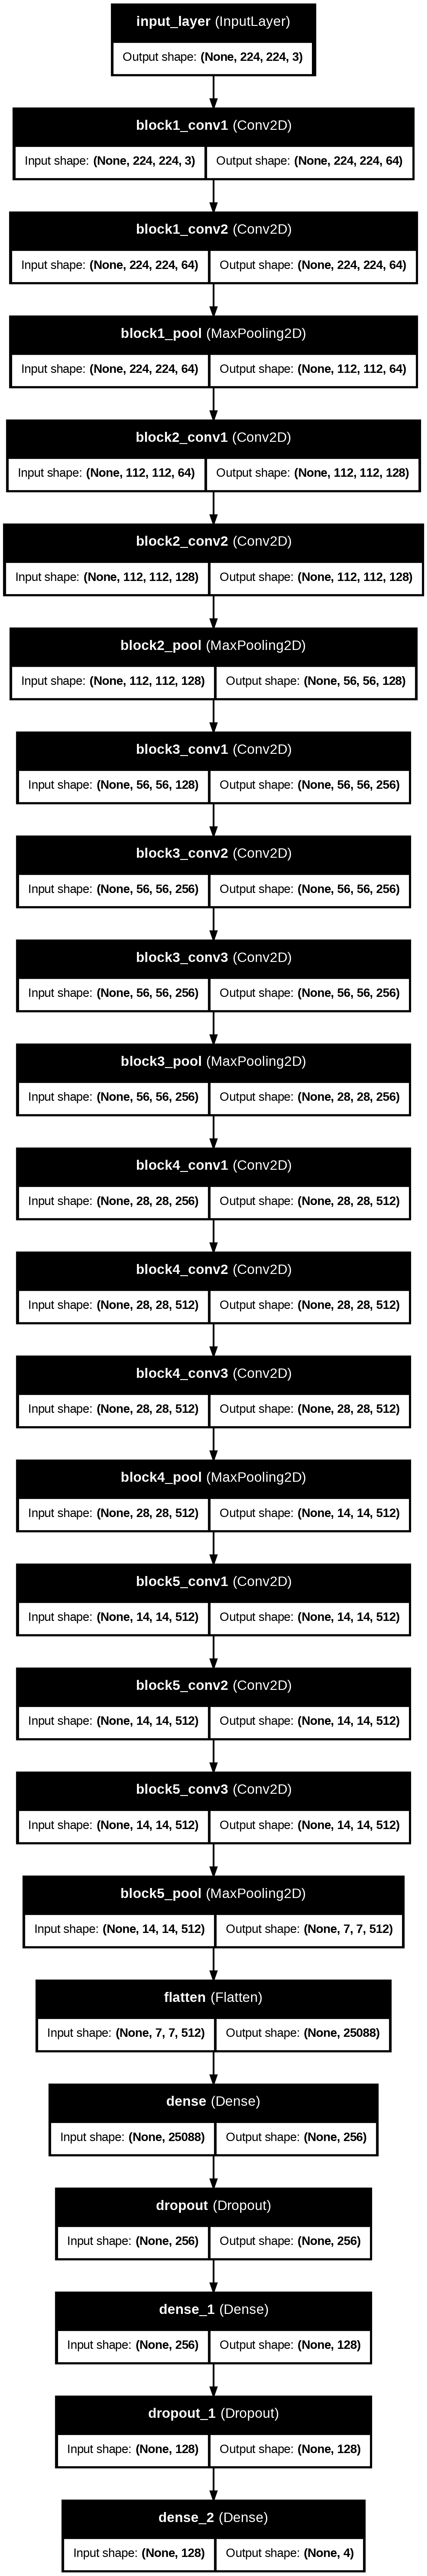

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.utils import plot_model

plot_model(
    VGG16_model,
    to_file='/content/drive/MyDrive/vgg16_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    expand_nested=False,
    dpi=200
)

from IPython.display import Image
Image('/content/drive/MyDrive/vgg16_architecture.png', width=800)

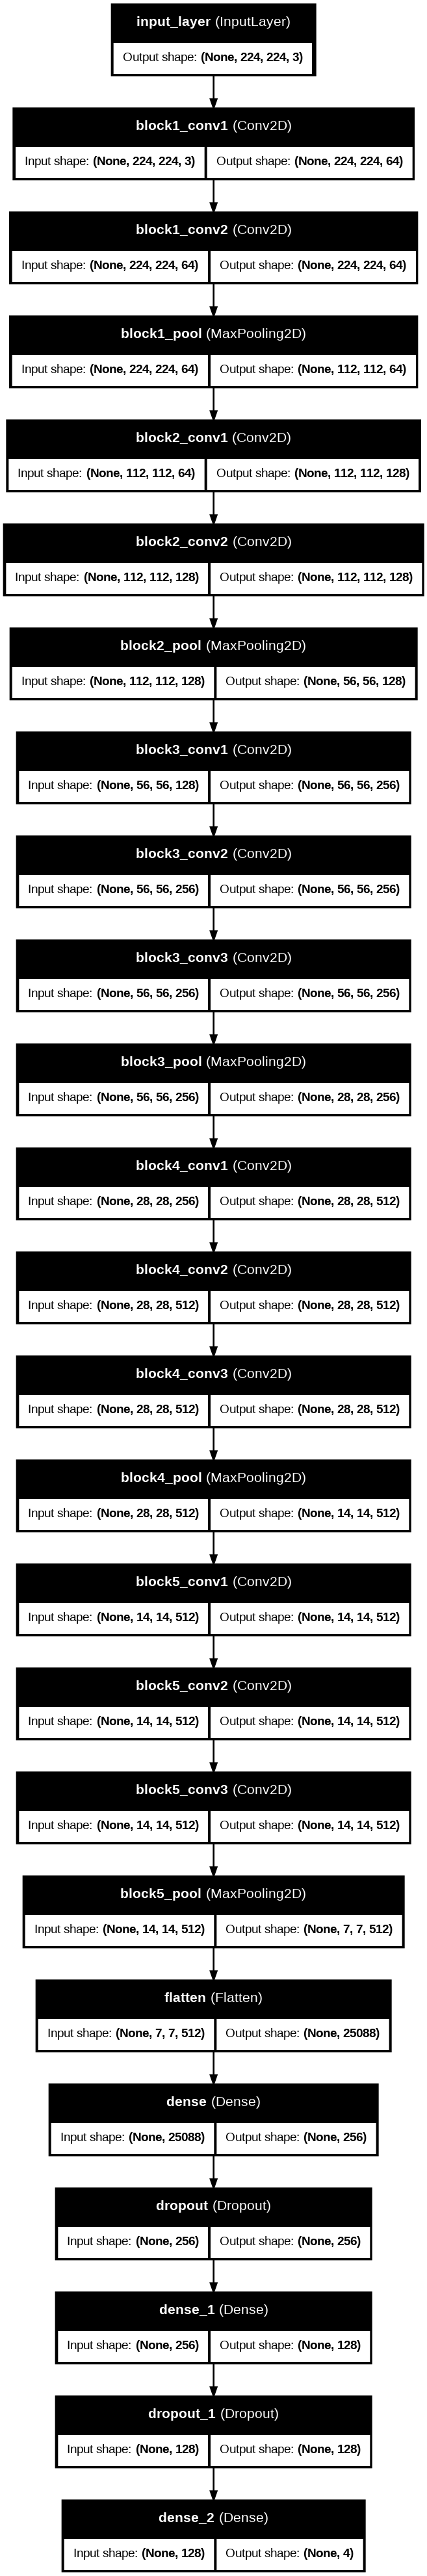

In [8]:
from IPython.display import Image
Image('/content/drive/MyDrive/vgg16_architecture.png')